<a href="https://colab.research.google.com/github/EmValdi/Modelo_Abalone/blob/main/Abalones_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [74]:
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd
#from pandas.tools.plotting import scatter_matrix
pd.set_option('display.width', 500)
pd.set_option('display.max_columns', 100)
pd.set_option('display.notebook_repr_html', True)
import seaborn as sns
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')
import string
import math
import sys
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import sklearn
from IPython.core.interactiveshell import InteractiveShell

InteractiveShell.ast_node_interactivity = "all"

# EDA: Exploratory Data Analysis

Primero se realiza un analisis de los datos existentes para saber cómo están compuestos y qué decisiones tomar en el preprocesamiento

In [75]:
#Usando pandas para leer el archivo y verificar tanto los datos, como sus tipos. Se comprueba también que no hay valores nulos
#y se obtienen valores como la media y desviación estándar de cada feature

df = pd.read_csv("abalone.data", names = ["sex","length","diameter", "height", "whole weight", "shucked weight", "viscera weight", "shell weight", "rings"])

df.head()

print("\n")

df.info()

print("\n")

print(df.isnull().sum())

print("\n")

df.describe(include="all")

,sex,length,diameter,height,whole weight,shucked weight,viscera weight,shell weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex             4177 non-null   object 
 1   length          4177 non-null   float64
 2   diameter        4177 non-null   float64
 3   height          4177 non-null   float64
 4   whole weight    4177 non-null   float64
 5   shucked weight  4177 non-null   float64
 6   viscera weight  4177 non-null   float64
 7   shell weight    4177 non-null   float64
 8   rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


sex               0
length            0
diameter          0
height            0
whole weight      0
shucked weight    0
viscera weight    0
shell weight      0
rings             0
dtype: int64




,sex,length,diameter,height,whole weight,shucked weight,viscera weight,shell weight,rings
count,4177,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
unique,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,NaN,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,NaN,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,NaN,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,NaN,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,NaN,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000


<Axes: xlabel='rings'>

[Text(0, 0, '1'),
 Text(1, 0, '2'),
 Text(2, 0, '3'),
 Text(3, 0, '4'),
 Text(4, 0, '5'),
 Text(5, 0, '6'),
 Text(6, 0, '7'),
 Text(7, 0, '8'),
 Text(8, 0, '9'),
 Text(9, 0, '10'),
 Text(10, 0, '11'),
 Text(11, 0, '12'),
 Text(12, 0, '13'),
 Text(13, 0, '14'),
 Text(14, 0, '15'),
 Text(15, 0, '16'),
 Text(16, 0, '17'),
 Text(17, 0, '18'),
 Text(18, 0, '19'),
 Text(19, 0, '20'),
 Text(20, 0, '21'),
 Text(21, 0, '22'),
 Text(22, 0, '23'),
 Text(23, 0, '24'),
 Text(24, 0, '25'),
 Text(25, 0, '26'),
 Text(26, 0, '27'),
 Text(27, 0, '29')]

Text(0, 0.5, 'Frequency Count')

Text(0.5, 1.0, 'Ring Count')

Text(0.0, 0.5, '1')

...

Text(23.0, 1.0, '2')

Text(24.0, 0.5, '1')

Text(25.0, 0.5, '1')

Text(26.0, 1.0, '2')

Text(27.0, 0.5, '1')

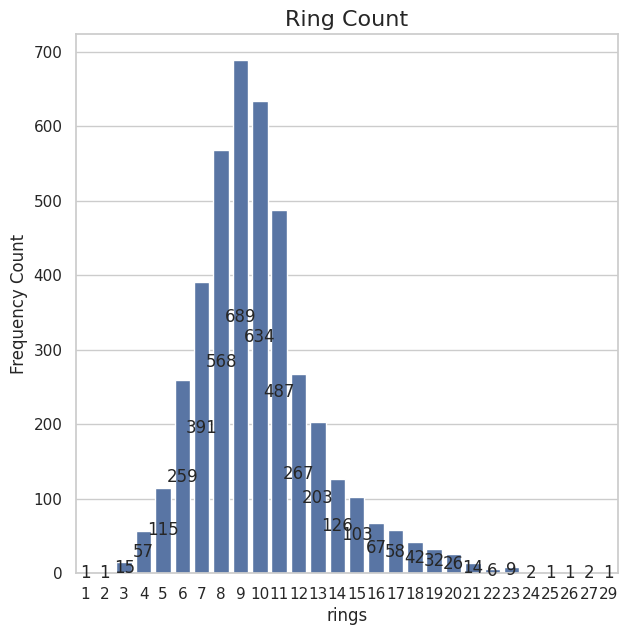

In [49]:
#La gran mayoría de los registros se encuentran entre 7 y 11 anillos y se cuenta con muy pocos valores en los extremos, particularmente el derecho.
#Esto puede afectar el modelo dificilmente reconozca los moluscos que son viejos

figure, ring_bar = plt.subplots(figsize=(7, 7))

rings_count = df["rings"].value_counts().sort_index()

sns.barplot(x= rings_count.index, y = rings_count.values, ax = ring_bar)

ring_bar.set_xticklabels(rings_count.index)
ring_bar.set_ylabel('Frequency Count')
ring_bar.set_title('Ring Count', fontsize = 16)

for patch in ring_bar.patches:
    label_x = patch.get_x() + patch.get_width()/2  # find midpoint of rectangle
    label_y = patch.get_y() + patch.get_height()/2
    ring_bar.text(label_x, label_y,
                #left - freq below - rel freq wrt population as a percentage
               str(int(patch.get_height())),
               horizontalalignment='center', verticalalignment='center')

sex
M    1528
I    1342
F    1307
Name: count, dtype: int64


<Axes: xlabel='sex', ylabel='count'>

[Text(0, 0, 'Male'), Text(1, 0, 'Infant'), Text(2, 0, 'Female')]

Text(0, 0.5, 'Frecuencia')

Text(0.5, 1.0, 'Distribucion de sexos')

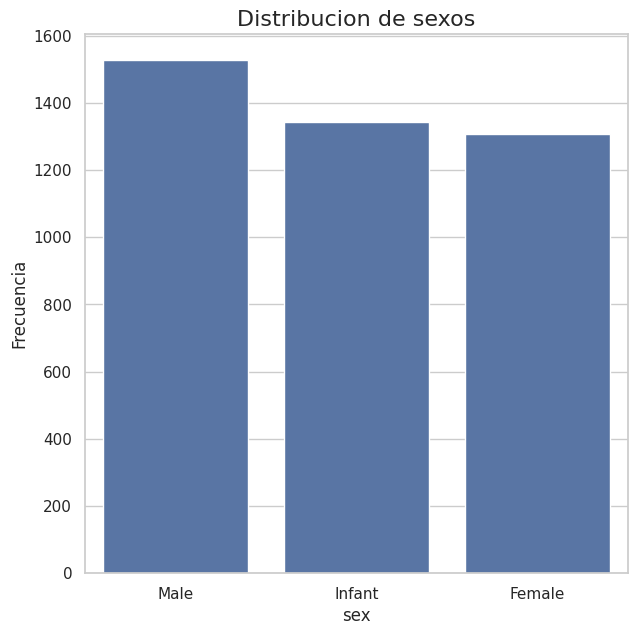

In [47]:
#Los sexos están distribuidos de manera relativamente uniforme. Esto será beneficioso para que el modelo pueda apreciar las características de cada
#grupo por igual.

print(df['sex'].value_counts())

figure, sex_bar = plt.subplots(figsize=(7, 7))
sns.barplot(x= df['sex'].value_counts().index, y = df['sex'].value_counts(), ax = sex_bar)
sex_bar.set_xticklabels(["Male", "Infant", "Female"])
sex_bar.set_ylabel('Frecuencia')
sex_bar.set_title('Distribucion de sexos', fontsize = 16)

<Axes: >

(7.0, 0.0)

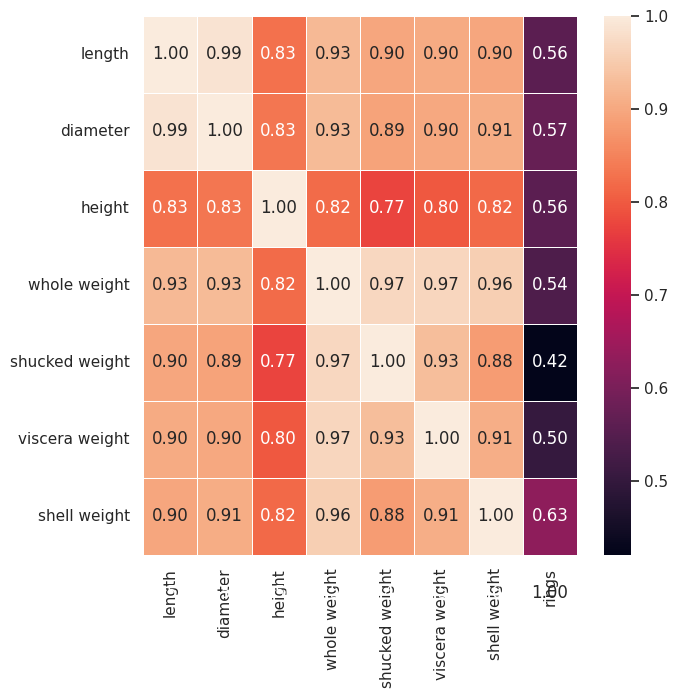

In [53]:
#Mapa de calor con las variables del dataset. Se aprecia que todas las variables están moderadamente relacionadas con los anillos (edad) del molusco.
#La variable más significativa es el peso de la concha (shell weight) y la menos significativa el peso de la carne removida (shucked weight).
#Por las relaciones entre features, podemos observar que hay algunas que son redundates, como longitud con diametro y los diferentes pesos, por lo que no
#se deberían usar todas para realizar predicciones en el modelo.

f,ax = plt.subplots(figsize=(7, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, linewidths=0.5, fmt='.2f',ax=ax)
ax.set_ylim(7, 0)

<Figure size 700x500 with 0 Axes>

<Axes: xlabel='sex', ylabel='rings'>

Text(0.5, 1.0, 'Sex vs Rings')

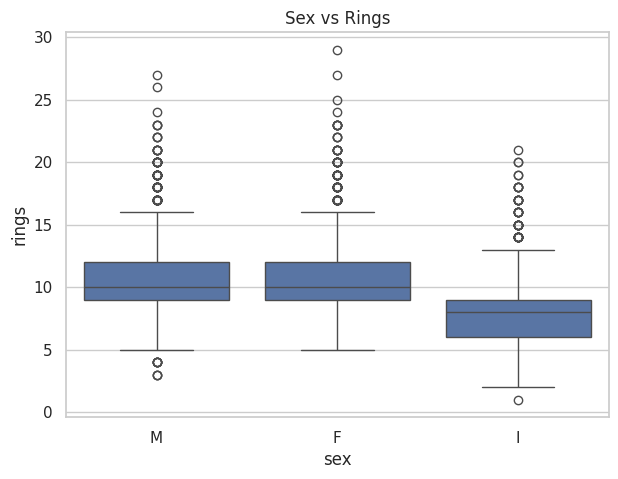

In [55]:
#Analizando la relación entre la variable de sexo y el número de anillos, podemos apreciar que los infantes presentan en general, menor tamaño y
#dispersión que machos y hembras, aunque no existe una diferencia significativa entre estos últimos dos.

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="sex",
    y="rings"
)

plt.title("Sex vs Rings")

plt.show()


In [57]:
#Hay 2 registros en los que height es 0. Lo mejor sería descartarlos para que esta informacion no afecte al modelo

print(df[df["height"] == 0])

print("Cantidad Height=0:",
      (df["height"] == 0).sum())


     sex  length  diameter  height  whole weight  shucked weight  viscera weight  shell weight  rings
1257   I   0.430      0.34     0.0         0.428          0.2065          0.0860        0.1150      8
3996   I   0.315      0.23     0.0         0.134          0.0575          0.0285        0.3505      6
Cantidad Height=0: 2


<Figure size 600x400 with 0 Axes>

<Axes: xlabel='length', ylabel='rings'>

Text(0.5, 1.0, 'length vs rings')

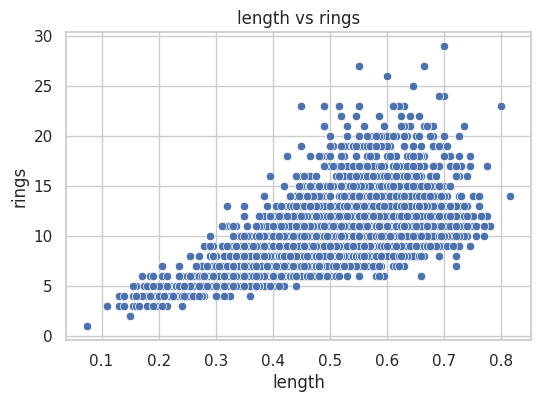

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='diameter', ylabel='rings'>

Text(0.5, 1.0, 'diameter vs rings')

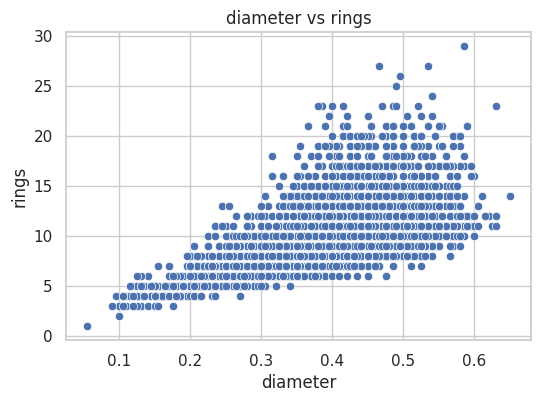

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='height', ylabel='rings'>

Text(0.5, 1.0, 'height vs rings')

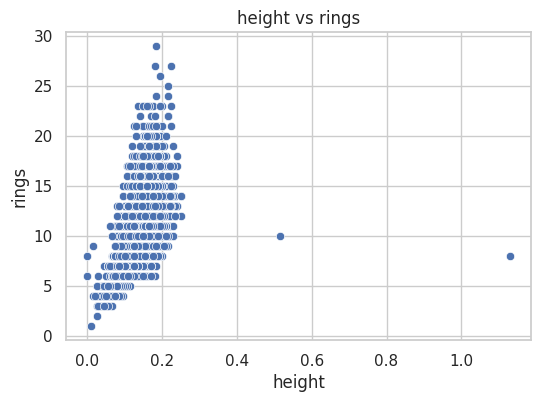

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='whole weight', ylabel='rings'>

Text(0.5, 1.0, 'whole weight vs rings')

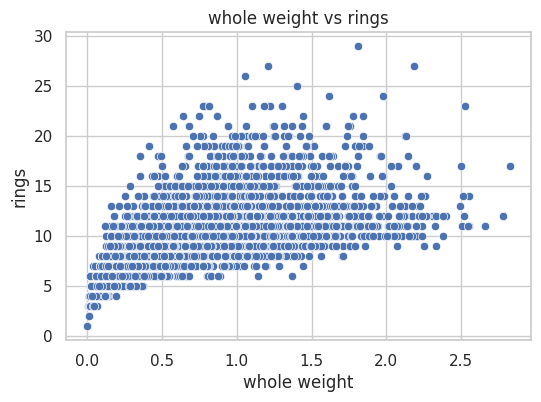

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='shucked weight', ylabel='rings'>

Text(0.5, 1.0, 'shucked weight vs rings')

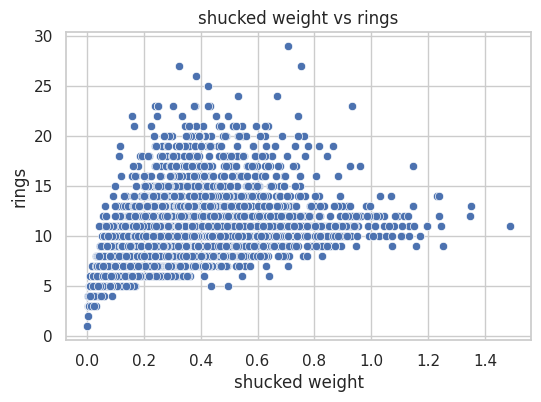

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='viscera weight', ylabel='rings'>

Text(0.5, 1.0, 'viscera weight vs rings')

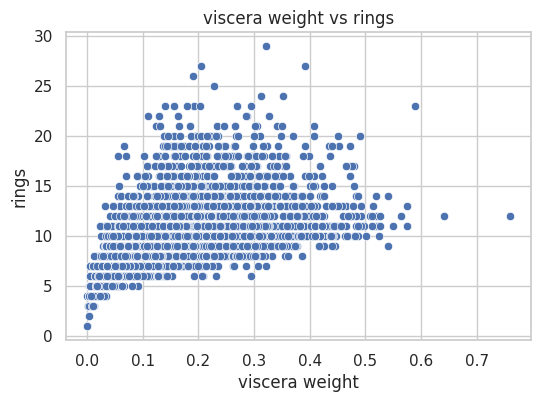

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='shell weight', ylabel='rings'>

Text(0.5, 1.0, 'shell weight vs rings')

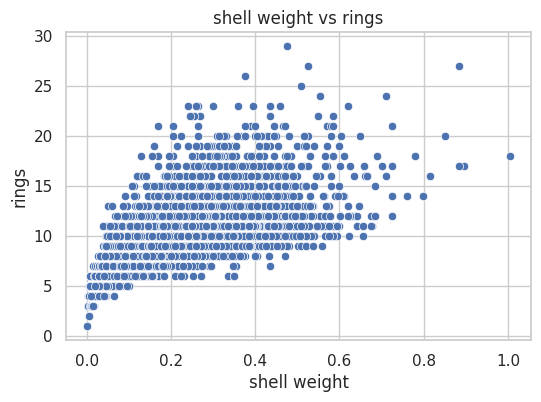

In [72]:
#Los gráficos de dispersión nos confirman que hay una gran similaridad entre las variables de longitud y diametro, así como las de
#peso entre ellas mismas. La gráfica de altura muestra que es la variable con menor crecimiento entre todas, además de presentar dos
#registros que destacan demasiado de los demás. Para el modelo, esto significa que no será beneficial incluir todas las variables, pues
#no mejorará la precisión. También es importante limpiar los valores extremos de la variable de altura para evitar sesgos por estos mismos

feature_cols = [
    col for col in numeric_cols
    if col != "rings"
]

for col in feature_cols:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        data=df,
        x=col,
        y="rings"
    )

    plt.title(f"{col} vs rings")

    plt.show()


Con base en el análisis exploratorio, se aplicará:
- One-hot encoding para la variable Sex.
- Escalado mediante StandardScaler para variables numéricas.
- Eliminación de outliers extremos en Height.
- Se utilizará Standard Scaler para escalar las magnitudes a números similares.

In [79]:
df = df[(df["height"] > 0) &(df["height"] < 0.4)]

x = df[["sex", "length", "diameter", "height", "whole weight", "shucked weight", "viscera weight", "shell weight"]]
y = df["rings"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

x_train = pd.get_dummies(
    x_train,
    columns=["sex"]
)

x_test = pd.get_dummies(
    x_test,
    columns=["sex"]
)

x_test

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.values.reshape(-1,1)
)

y_test_scaled = y_scaler.transform(
    y_test.values.reshape(-1,1)
)

,length,diameter,height,whole weight,shucked weight,viscera weight,shell weight,sex_F,sex_I,sex_M
501,0.620,0.520,0.225,1.1835,0.3780,0.2700,0.3950,True,False,False
463,0.220,0.165,0.055,0.0545,0.0215,0.0120,0.0200,False,True,False
1426,0.745,0.570,0.215,2.2500,1.1565,0.4460,0.5580,True,False,False
1463,0.505,0.385,0.105,0.5525,0.2390,0.1245,0.1555,False,False,True
3026,0.495,0.375,0.115,0.5070,0.2410,0.1030,0.1500,False,True,False
...,...,...,...,...,...,...,...,...,...,...
1269,0.470,0.365,0.100,0.4110,0.1750,0.0855,0.1350,False,True,False
1742,0.680,0.510,0.200,1.6075,0.7140,0.3390,0.4705,True,False,False
2515,0.470,0.375,0.120,0.6015,0.2765,0.1455,0.1350,True,False,False
1869,0.525,0.400,0.145,0.6095,0.2480,0.1590,0.1750,False,True,False
